### Imports

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [111]:
!pip install -q snntorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Dataset, DataLoader, TensorDataset
import snntorch as snn
from snntorch import surrogate

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tqdm.auto import tqdm

### Configuration

In [112]:
# Configuration

SEED = 42

WINDOW = 24          # Use the previous 3 hours (12 × 15 min)
HORIZON = 1          # Predict the next 15-minute interval

BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 1e-4

In [113]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


### Load Dataset

In [114]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/kyleahmurphy/uk-electrical-load/House_2.csv")

df["Time"] = pd.to_datetime(df["Time"])
df = df.sort_values("Time")

# Keep aggregate + individual appliances
power_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9"
]

df = df[["Time"] + power_cols].dropna()

# Resample to 15-minute average
df = (
    df.set_index("Time")
      .resample("15min")[power_cols]
      .mean()
      .dropna()
      .reset_index()
)

# Time-of-day features
hour = (
    df["Time"].dt.hour
    + df["Time"].dt.minute / 60
)

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

print(df.shape)
print(df.head())

(45093, 13)
                 Time   Aggregate  Appliance1  Appliance2  Appliance3  \
0 2013-09-17 22:00:00  713.370968   86.580645         0.0         0.0   
1 2013-09-17 22:15:00  502.266667   75.340000         0.0         0.0   
2 2013-09-17 22:30:00   91.666667    1.006667         0.0         0.0   
3 2013-09-17 22:45:00   60.344371    1.000000         0.0         0.0   
4 2013-09-17 23:00:00   60.161074    1.000000         0.0         0.0   

   Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  Appliance9  \
0         0.0         0.0         0.0         0.0         0.0         0.0   
1         0.0         0.0         0.0         0.0         0.0         0.0   
2         0.0         0.0         0.0         0.0         0.0         0.0   
3         0.0         0.0         0.0         0.0         0.0         0.0   
4         0.0         0.0         0.0         0.0         0.0         0.0   

   hour_sin  hour_cos  
0 -0.500000  0.866025  
1 -0.442289  0.896873  
2 -0.382683  0

In [115]:
# Create t+15 target

df["Target"] = df["Aggregate"].shift(-HORIZON)

df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.shape)

                 Time   Aggregate  Appliance1  Appliance2  Appliance3  \
0 2013-09-17 22:00:00  713.370968   86.580645         0.0         0.0   
1 2013-09-17 22:15:00  502.266667   75.340000         0.0         0.0   
2 2013-09-17 22:30:00   91.666667    1.006667         0.0         0.0   
3 2013-09-17 22:45:00   60.344371    1.000000         0.0         0.0   
4 2013-09-17 23:00:00   60.161074    1.000000         0.0         0.0   

   Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  Appliance9  \
0         0.0         0.0         0.0         0.0         0.0         0.0   
1         0.0         0.0         0.0         0.0         0.0         0.0   
2         0.0         0.0         0.0         0.0         0.0         0.0   
3         0.0         0.0         0.0         0.0         0.0         0.0   
4         0.0         0.0         0.0         0.0         0.0         0.0   

   hour_sin  hour_cos      Target  
0 -0.500000  0.866025  502.266667  
1 -0.442289  0.896873   91

### Preprocessing

In [116]:
# Chronological split

n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain:", train_df["Time"].min(), "→", train_df["Time"].max())
print("Val:  ", val_df["Time"].min(), "→", val_df["Time"].max())
print("Test: ", test_df["Time"].min(), "→", test_df["Time"].max())

Train: (31564, 14)
Validation: (6764, 14)
Test: (6764, 14)

Train: 2013-09-17 22:00:00 → 2014-12-21 03:30:00
Val:   2014-12-21 03:45:00 → 2015-03-01 16:00:00
Test:  2015-03-01 16:15:00 → 2015-05-28 07:45:00


In [117]:
power_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9"
]

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df[power_cols])
val_scaled = scaler.transform(val_df[power_cols])
test_scaled = scaler.transform(test_df[power_cols])

print("train_scaled:", train_scaled.shape)

train_scaled: (31564, 10)


In [118]:
# Create input sequences
# Features used as model input
feature_cols = [
    "Aggregate",
    "Appliance1", "Appliance2", "Appliance3",
    "Appliance4", "Appliance5", "Appliance6",
    "Appliance7", "Appliance8", "Appliance9",
    "hour_sin",
    "hour_cos"
]

def create_sequences(scaled_power, df_split, window=WINDOW):
    X = []
    y = []
    current_values = []

    hour_sin = df_split["hour_sin"].values
    hour_cos = df_split["hour_cos"].values

    for i in range(len(scaled_power) - window):

        # 24-timestep input
        sequence = np.column_stack([
            scaled_power[i:i + window],
            hour_sin[i:i + window],
            hour_cos[i:i + window]
        ])

        X.append(sequence)

        # Current Aggregate = last timestep in window
        current_aggregate = scaled_power[i + window - 1, 0]

        # Future Aggregate = next timestep (t+15)
        future_aggregate = scaled_power[i + window, 0]

        # Predict change
        delta = future_aggregate - current_aggregate

        y.append(delta)
        current_values.append(current_aggregate)

    return (
        np.array(X),
        np.array(y).reshape(-1, 1),
        np.array(current_values).reshape(-1, 1)
    )
    
X_train, y_train, current_train = create_sequences(train_scaled, train_df)
X_val, y_val, current_val = create_sequences(val_scaled, val_df)
X_test, y_test, current_test = create_sequences(test_scaled, test_df)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (31540, 24, 12)
y_train: (31540, 1)


In [119]:
X_train, y_train, current_train = create_sequences(
    train_scaled, train_df
)

X_val, y_val, current_val = create_sequences(
    val_scaled, val_df
)

X_test, y_test, current_test = create_sequences(
    test_scaled, test_df
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (31540, 24, 12)
y_train: (31540, 1)


In [120]:
# Create DataLoaders

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(current_train, dtype=torch.float32)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
        torch.tensor(current_val, dtype=torch.float32)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32),
        torch.tensor(current_test, dtype=torch.float32)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 247
Validation batches: 53
Test batches: 53


### Neural Network

In [121]:
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate


class SNNForecaster(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(12, 32)
        self.lif1 = snn.Leaky(
            beta=0.9,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(32, 16)
        self.lif2 = snn.Leaky(
            beta=0.9,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.output = nn.Linear(16, 1)

    def forward(self, x):
        # x: [batch, time, features]
        batch_size = x.size(0)

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        outputs = []

        for t in range(x.size(1)):
            cur1 = self.fc1(x[:, t, :])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            out = self.output(spk2)
            outputs.append(out)

        # Use the final timestep for the forecast
        return outputs[-1]


model = SNNForecaster().to(DEVICE)

print(model)

SNNForecaster(
  (fc1): Linear(in_features=12, out_features=32, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (lif2): Leaky()
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [122]:
# Loss and optimizer

criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

### Training Loop

In [123]:
# Training loop

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch, _ in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch, _ in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train: {train_loss:.4f} | "
        f"Val: {val_loss:.4f}"
    )

Epoch 01/30 | Train: 1.2644 | Val: 1.3117
Epoch 02/30 | Train: 1.2582 | Val: 1.3062
Epoch 03/30 | Train: 1.2473 | Val: 1.3004
Epoch 04/30 | Train: 1.2448 | Val: 1.2916
Epoch 05/30 | Train: 1.2364 | Val: 1.2833
Epoch 06/30 | Train: 1.2301 | Val: 1.2794
Epoch 07/30 | Train: 1.2267 | Val: 1.2729
Epoch 08/30 | Train: 1.2205 | Val: 1.2695
Epoch 09/30 | Train: 1.2146 | Val: 1.2623
Epoch 10/30 | Train: 1.2054 | Val: 1.2600
Epoch 11/30 | Train: 1.2040 | Val: 1.2580
Epoch 12/30 | Train: 1.1959 | Val: 1.2630
Epoch 13/30 | Train: 1.2015 | Val: 1.2564
Epoch 14/30 | Train: 1.1904 | Val: 1.2438
Epoch 15/30 | Train: 1.1898 | Val: 1.2444
Epoch 16/30 | Train: 1.1869 | Val: 1.2459
Epoch 17/30 | Train: 1.1795 | Val: 1.2505
Epoch 18/30 | Train: 1.1770 | Val: 1.2505
Epoch 19/30 | Train: 1.1743 | Val: 1.2443
Epoch 20/30 | Train: 1.1676 | Val: 1.2411
Epoch 21/30 | Train: 1.1647 | Val: 1.2410
Epoch 22/30 | Train: 1.1614 | Val: 1.2496
Epoch 23/30 | Train: 1.1545 | Val: 1.2412
Epoch 24/30 | Train: 1.1526 | Val:

### Evaluation

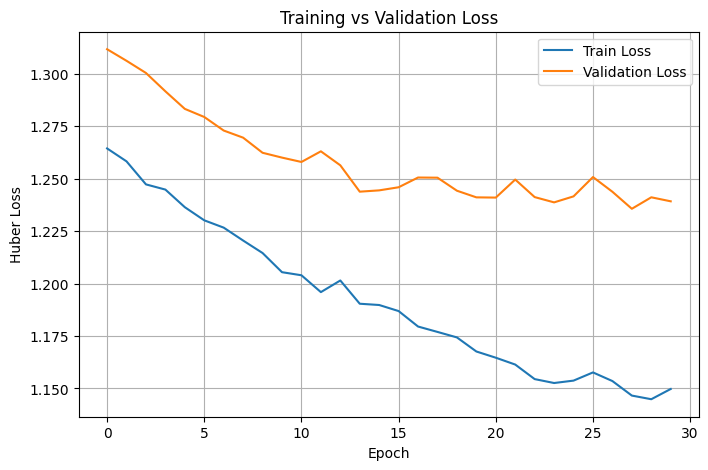

In [124]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [125]:
# Generate test predictions

model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch, _ in test_loader:
        X_batch = X_batch.to(DEVICE)

        pred = model(X_batch)

        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

predictions = np.concatenate(predictions).flatten()
actuals = np.concatenate(actuals).flatten()

# Convert Aggregate predictions back to watts
# Aggregate is column 0 of the scaler
predictions_watts = (
    predictions * scaler.scale_[0] + scaler.mean_[0]
)

actuals_watts = (
    actuals * scaler.scale_[0] + scaler.mean_[0]
)

# Metrics
mae = mean_absolute_error(
    actuals_watts,
    predictions_watts
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_watts,
        predictions_watts
    )
)

r2 = r2_score(
    actuals_watts,
    predictions_watts
)

print(f"MAE:  {mae:.2f} W")
print(f"RMSE: {rmse:.2f} W")
print(f"R²:   {r2:.4f}")

MAE:  331.51 W
RMSE: 830.77 W
R²:   0.0651


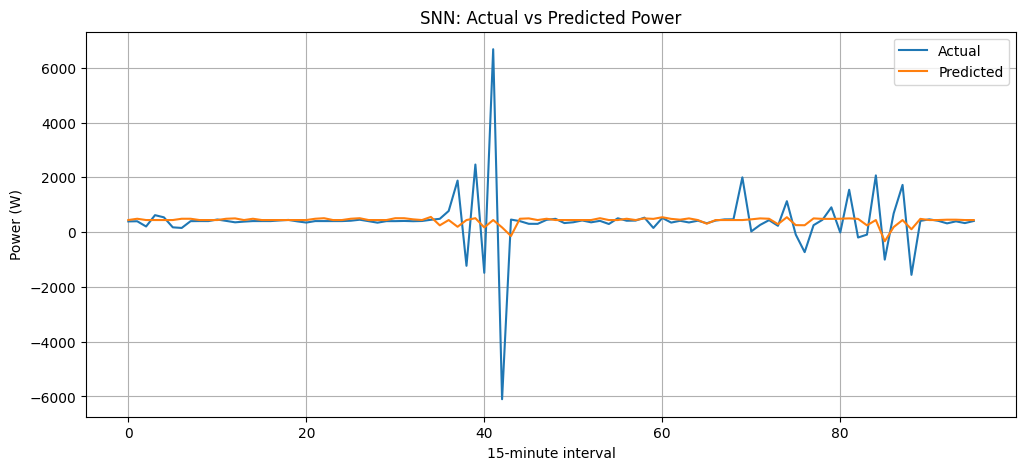

In [126]:
# Plot actual vs predicted power

points = 96       # 24 hours × 4 intervals/hour

plt.figure(figsize=(12, 5))

plt.plot(
    actuals_watts[:points],
    label="Actual"
)

plt.plot(
    predictions_watts[:points],
    label="Predicted"
)

plt.xlabel("15-minute interval")
plt.ylabel("Power (W)")
plt.title("SNN: Actual vs Predicted Power")
plt.legend()
plt.grid(True)

plt.show()

In [127]:
# Predict the next 15-minute value as the current value

baseline_pred = test_df["Aggregate"].values[:-1]
baseline_actual = test_df["Aggregate"].values[1:]

baseline_mae = mean_absolute_error(
    baseline_actual,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(baseline_actual, baseline_pred)
)

baseline_r2 = r2_score(
    baseline_actual,
    baseline_pred
)

print(f"Baseline MAE:  {baseline_mae:.2f} W")
print(f"Baseline RMSE: {baseline_rmse:.2f} W")
print(f"Baseline R²:   {baseline_r2:.4f}")

Baseline MAE:  309.26 W
Baseline RMSE: 859.10 W
Baseline R²:   -0.0394


In [128]:
print("Current vs next correlation:",
      np.corrcoef(
          test_df["Aggregate"].values[:-1],
          test_df["Aggregate"].values[1:]
      )[0, 1])

Current vs next correlation: 0.4791190886108385
